# Confidence Intervals

Topic 03 of the Statistical Inference & Hypothesis Testing repo. Topics 01-02 built the sampling distribution and confirmed $SE = \sigma/\sqrt{n}$ empirically. A confidence interval turns that standard error into a *range* of plausible parameter values — this notebook builds one from scratch, then does the one thing most explanations skip: directly simulates thousands of intervals to check whether a '95% confidence interval' actually contains the true parameter 95% of the time, and confronts the single most common misinterpretation of what a CI means head-on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. What Is a Confidence Interval? A First Construction

When $\sigma$ is known, a $(1-\alpha)$ confidence interval for the mean is

$$\bar{X} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

where $z_{\alpha/2}$ is the critical value cutting off $\alpha/2$ in each tail of the standard Normal.

In [2]:
true_mu, true_sigma = 100, 15
population = np.random.normal(true_mu, true_sigma, size=200000)

n = 40
sample = np.random.choice(population, size=n, replace=False)
sample_mean = sample.mean()

z_critical = stats.norm.ppf(0.975)  # for a 95% CI
margin_of_error = z_critical * (true_sigma / np.sqrt(n))
ci_lower, ci_upper = sample_mean - margin_of_error, sample_mean + margin_of_error

print(f"True population mean: {true_mu}")
print(f"Sample mean (n={n}): {sample_mean:.4f}")
print(f"z_critical (95% CI): {z_critical:.4f}")
print(f"Margin of error: {margin_of_error:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Does this interval contain the true mean? {ci_lower <= true_mu <= ci_upper}")

True population mean: 100
Sample mean (n=40): 96.8981
z_critical (95% CI): 1.9600
Margin of error: 4.6485
95% CI: [92.2497, 101.5466]
Does this interval contain the true mean? True


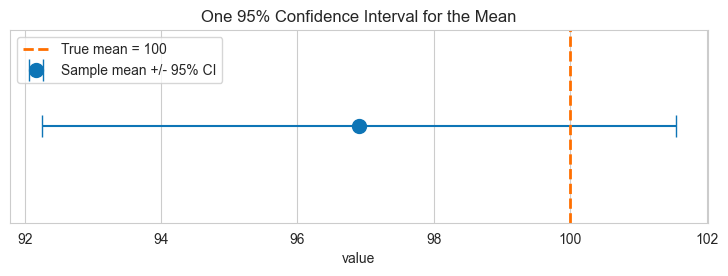

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.errorbar([sample_mean], [0], xerr=[[sample_mean - ci_lower], [ci_upper - sample_mean]],
            fmt="o", color="#0e75b6", capsize=8, markersize=10, label="Sample mean +/- 95% CI")
ax.axvline(true_mu, color="#FF6F00", linestyle="--", linewidth=2, label=f"True mean = {true_mu}")
ax.set_yticks([])
ax.set_xlabel("value")
ax.set_title("One 95% Confidence Interval for the Mean")
ax.legend()
plt.show()

## 2. Coverage Probability: Does '95%' Actually Mean 95%?

A 95% CI's defining property is about its *construction procedure*, not any single interval: if you built this exact interval from 10,000 independent samples, roughly 95% of those intervals should contain the true parameter. This section tests that claim directly by simulation instead of asserting it.

In [4]:
def build_z_confidence_interval(sample, known_sigma, confidence_level):
    n = len(sample)
    z_crit = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    margin = z_crit * (known_sigma / np.sqrt(n))
    mean = sample.mean()
    return mean - margin, mean + margin

n_coverage_test = 40
n_repeats_coverage = 10000
confidence_level = 0.95
rng = np.random.default_rng(10)

contains_true_mean = np.empty(n_repeats_coverage, dtype=bool)
for i in range(n_repeats_coverage):
    sample_i = rng.choice(population, size=n_coverage_test, replace=False)
    lower, upper = build_z_confidence_interval(sample_i, true_sigma, confidence_level)
    contains_true_mean[i] = lower <= true_mu <= upper

empirical_coverage = contains_true_mean.mean()
print(f"Nominal confidence level: {confidence_level * 100:.0f}%")
print(f"Empirical coverage across {n_repeats_coverage} independently constructed intervals: {empirical_coverage * 100:.2f}%")
print(f"Difference from nominal: {abs(empirical_coverage - confidence_level) * 100:.2f} percentage points")
assert abs(empirical_coverage - confidence_level) < 0.02
print("Confirmed: the empirical coverage matches the nominal 95% to within Monte Carlo noise.")

Nominal confidence level: 95%
Empirical coverage across 10000 independently constructed intervals: 95.05%
Difference from nominal: 0.05 percentage points
Confirmed: the empirical coverage matches the nominal 95% to within Monte Carlo noise.


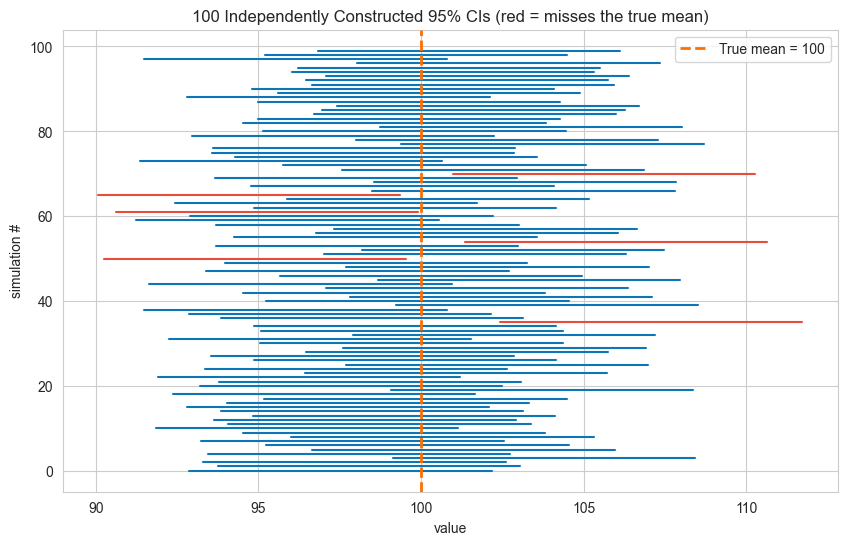

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
n_display = 100
rng_display = np.random.default_rng(11)
for i in range(n_display):
    sample_i = rng_display.choice(population, size=n_coverage_test, replace=False)
    lower, upper = build_z_confidence_interval(sample_i, true_sigma, confidence_level)
    covers = lower <= true_mu <= upper
    color = "#0e75b6" if covers else "#e74c3c"
    ax.plot([lower, upper], [i, i], color=color, linewidth=1.5)
ax.axvline(true_mu, color="#FF6F00", linestyle="--", linewidth=2, label=f"True mean = {true_mu}", zorder=10)
ax.set_xlabel("value")
ax.set_ylabel("simulation #")
ax.set_title(f"{n_display} Independently Constructed 95% CIs (red = misses the true mean)")
ax.legend()
plt.show()

In [6]:
rng_display2 = np.random.default_rng(11)
miss_count = 0
for i in range(n_display):
    sample_i = rng_display2.choice(population, size=n_coverage_test, replace=False)
    lower, upper = build_z_confidence_interval(sample_i, true_sigma, confidence_level)
    if not (lower <= true_mu <= upper):
        miss_count += 1
print(f"Out of {n_display} displayed intervals, {miss_count} missed the true mean "
      f"({100 * miss_count / n_display:.1f}%) -- close to the expected 5% miss rate.")

Out of 100 displayed intervals, 6 missed the true mean (6.0%) -- close to the expected 5% miss rate.


## 3. The Correct Interpretation vs. the Common Misinterpretation

**Wrong**: "There is a 95% probability that the true mean lies in this specific interval." Once an interval is computed from one sample, the true mean either is or isn't in it — there's no probability left, only 0 or 1.

**Correct**: "If this procedure were repeated many times, about 95% of the resulting intervals would contain the true mean." The randomness is in the *procedure across samples*, not in the true parameter or any one already-computed interval. Section 2's 10,000-interval simulation is a direct visualization of the correct interpretation — the true mean was never random, only the interval's endpoints were.

In [7]:
single_realized_ci = build_z_confidence_interval(sample, true_sigma, 0.95)
print(f"This one realized interval: [{single_realized_ci[0]:.4f}, {single_realized_ci[1]:.4f}]")
print(f"Does it contain the true mean ({true_mu})? {single_realized_ci[0] <= true_mu <= single_realized_ci[1]}")
print()
print("This is now a FACT about this specific interval (True or False), not a 95% probability statement.")
print(f"The 95% guarantee applies to the empirical coverage measured across all {n_repeats_coverage} "
      f"simulated intervals in Section 2 ({empirical_coverage * 100:.2f}%), which IS the correct object "
      f"the '95%' refers to.")

This one realized interval: [92.2497, 101.5466]
Does it contain the true mean (100)? True

This is now a FACT about this specific interval (True or False), not a 95% probability statement.
The 95% guarantee applies to the empirical coverage measured across all 10000 simulated intervals in Section 2 (95.05%), which IS the correct object the '95%' refers to.


## 4. When $\sigma$ Is Unknown: the t-Distribution

In practice $\sigma$ is almost never known — it has to be estimated from the sample as $s$ (using ddof=1, per Topic 02). Substituting an estimated $s$ for the true $\sigma$ adds extra uncertainty, which the Normal distribution doesn't account for. The correct interval uses Student's t-distribution instead:

$$\bar{X} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}$$

In [8]:
def build_t_confidence_interval(sample, confidence_level):
    n = len(sample)
    sample_mean = sample.mean()
    sample_std = sample.std(ddof=1)
    t_crit = stats.t.ppf(1 - (1 - confidence_level) / 2, df=n - 1)
    margin = t_crit * (sample_std / np.sqrt(n))
    return sample_mean - margin, sample_mean + margin

t_ci = build_t_confidence_interval(sample, 0.95)
z_ci_with_estimated_sigma = build_z_confidence_interval(sample, sample.std(ddof=1), 0.95)

print(f"t-based 95% CI (correct):                [{t_ci[0]:.4f}, {t_ci[1]:.4f}]  width={t_ci[1]-t_ci[0]:.4f}")
print(f"z-based 95% CI (using estimated s, WRONG): [{z_ci_with_estimated_sigma[0]:.4f}, {z_ci_with_estimated_sigma[1]:.4f}]  width={z_ci_with_estimated_sigma[1]-z_ci_with_estimated_sigma[0]:.4f}")
print(f"\nThe t-interval is wider -- it correctly accounts for the extra uncertainty "
      f"from estimating sigma, which the z-interval ignores.")

t-based 95% CI (correct):                [91.7757, 102.0205]  width=10.2448
z-based 95% CI (using estimated s, WRONG): [91.9346, 101.8617]  width=9.9271

The t-interval is wider -- it correctly accounts for the extra uncertainty from estimating sigma, which the z-interval ignores.


In [9]:
n_small_values = [5, 10, 30, 100]
t_vs_z_rows = []
for n_small in n_small_values:
    t_crit = stats.t.ppf(0.975, df=n_small - 1)
    z_crit = stats.norm.ppf(0.975)
    t_vs_z_rows.append({"n": n_small, "df": n_small - 1, "t_critical": round(t_crit, 4),
                         "z_critical": round(z_crit, 4), "ratio_t_to_z": round(t_crit / z_crit, 4)})
t_vs_z_df = pd.DataFrame(t_vs_z_rows)
print(t_vs_z_df.to_string(index=False))
print("\nAs n grows, t_critical converges to z_critical -- the t-distribution's extra-wide tails "
      "(accounting for estimated sigma's uncertainty) matter most at small n and become negligible by n=100.")

  n  df  t_critical  z_critical  ratio_t_to_z
  5   4      2.7764        1.96        1.4166
 10   9      2.2622        1.96        1.1542
 30  29      2.0452        1.96        1.0435
100  99      1.9842        1.96        1.0124

As n grows, t_critical converges to z_critical -- the t-distribution's extra-wide tails (accounting for estimated sigma's uncertainty) matter most at small n and become negligible by n=100.


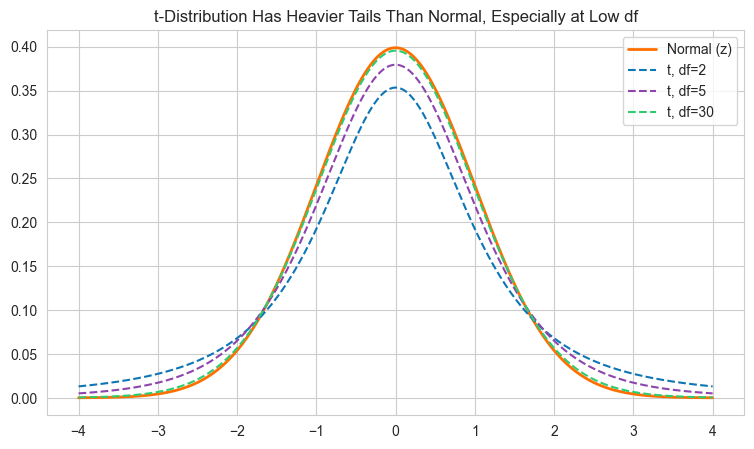

In [10]:
fig, ax = plt.subplots()
x_range = np.linspace(-4, 4, 400)
ax.plot(x_range, stats.norm.pdf(x_range), color="#FF6F00", linewidth=2, label="Normal (z)")
for df, color in zip([2, 5, 30], ["#0e75b6", "#8e44ad", "#2ecc71"]):
    ax.plot(x_range, stats.t.pdf(x_range, df=df), linestyle="--", color=color, label=f"t, df={df}")
ax.set_title("t-Distribution Has Heavier Tails Than Normal, Especially at Low df")
ax.legend()
plt.show()

### One-Sided Confidence Intervals

Everything so far has been a *two-sided* interval. Sometimes only a lower or upper bound matters -- e.g. "we are 95% confident the true mean is AT LEAST this value." A one-sided interval uses the FULL $\alpha$ in one tail instead of splitting it, so its single critical value is smaller than the two-sided $z_{\alpha/2}$.

In [11]:
def build_one_sided_lower_bound(sample, known_sigma, confidence_level):
    n = len(sample)
    z_crit_one_sided = stats.norm.ppf(confidence_level)  # full alpha in one tail
    margin = z_crit_one_sided * (known_sigma / np.sqrt(n))
    return sample.mean() - margin  # "true mean is at least this" lower bound

one_sided_lower = build_one_sided_lower_bound(sample, true_sigma, 0.95)
two_sided_lower = build_z_confidence_interval(sample, true_sigma, 0.95)[0]

print(f"Two-sided 95% CI lower bound: {two_sided_lower:.4f}")
print(f"One-sided 95% lower bound:    {one_sided_lower:.4f}")
print(f"\nThe one-sided bound is higher (tighter) than the two-sided lower bound, because "
      f"it doesn't need to reserve any of the 5% error budget for an upper-tail miss.")
assert one_sided_lower > two_sided_lower
print("Confirmed: the one-sided lower bound is strictly higher, as expected.")

Two-sided 95% CI lower bound: 92.2497
One-sided 95% lower bound:    92.9970

The one-sided bound is higher (tighter) than the two-sided lower bound, because it doesn't need to reserve any of the 5% error budget for an upper-tail miss.
Confirmed: the one-sided lower bound is strictly higher, as expected.


## 5. Interval Width: Effect of Sample Size and Confidence Level

Two separate knobs control a CI's width: sample size $n$ (more data always narrows it, at rate $1/\sqrt{n}$) and confidence level (higher confidence always widens it, since a wider net is needed to 'catch' the true parameter more often).

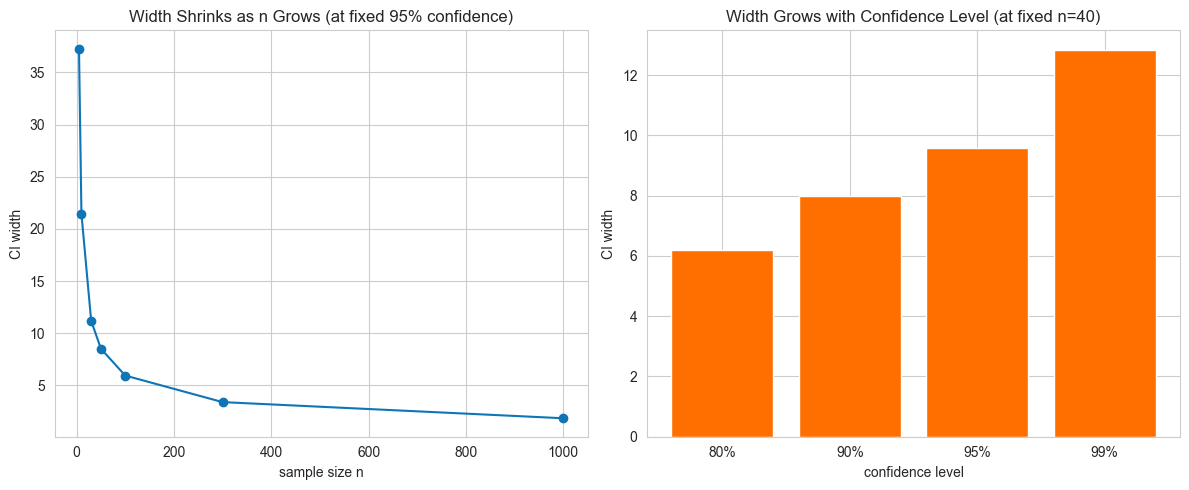

80% CI width at n=40: 6.1837
90% CI width at n=40: 7.9921
95% CI width at n=40: 9.5945
99% CI width at n=40: 12.8448


In [12]:
n_range = np.array([5, 10, 30, 50, 100, 300, 1000])
widths_by_n = 2 * stats.t.ppf(0.975, df=n_range - 1) * (true_sigma / np.sqrt(n_range))

confidence_levels_range = [0.80, 0.90, 0.95, 0.99]
widths_by_confidence = [2 * stats.t.ppf(1 - (1 - cl) / 2, df=39) * (true_sigma / np.sqrt(40)) for cl in confidence_levels_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(n_range, widths_by_n, marker="o", color="#0e75b6")
axes[0].set_xlabel("sample size n")
axes[0].set_ylabel("CI width")
axes[0].set_title("Width Shrinks as n Grows (at fixed 95% confidence)")

axes[1].bar([f"{int(cl*100)}%" for cl in confidence_levels_range], widths_by_confidence, color="#FF6F00")
axes[1].set_xlabel("confidence level")
axes[1].set_ylabel("CI width")
axes[1].set_title("Width Grows with Confidence Level (at fixed n=40)")
plt.tight_layout()
plt.show()

for cl, w in zip(confidence_levels_range, widths_by_confidence):
    print(f"{int(cl*100)}% CI width at n=40: {w:.4f}")

### Working Backwards: Minimum Sample Size for a Target Margin of Error

Solving the margin-of-error formula for $n$ instead of the interval:

$$n = \left(\frac{z_{\alpha/2} \cdot \sigma}{E}\right)^2$$

where $E$ is the desired maximum margin of error. This is the calculation behind "how many survey responses do we need" style questions.

In [13]:
def minimum_n_for_margin(sigma, target_margin, confidence_level):
    z_crit = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    return int(np.ceil((z_crit * sigma / target_margin) ** 2))

target_margins = [1, 2, 5, 10]
sample_size_rows = []
for margin in target_margins:
    n_needed = minimum_n_for_margin(true_sigma, margin, 0.95)
    sample_size_rows.append({"target_margin_of_error": margin, "n_needed": n_needed})

sample_size_df = pd.DataFrame(sample_size_rows)
print(f"Population sigma = {true_sigma}, target confidence = 95%")
print(sample_size_df.to_string(index=False))
print("\nHalving the target margin of error (e.g. 10 -> 5) roughly QUADRUPLES the required sample size -- "
      "the same 1/sqrt(n) relationship from Topic 01's standard-error formula, now solved for n directly.")

Population sigma = 15, target confidence = 95%
 target_margin_of_error  n_needed
                      1       865
                      2       217
                      5        35
                     10         9

Halving the target margin of error (e.g. 10 -> 5) roughly QUADRUPLES the required sample size -- the same 1/sqrt(n) relationship from Topic 01's standard-error formula, now solved for n directly.


## 6. Bootstrap Confidence Intervals

The t-interval assumes (approximate) Normality of the sampling distribution. The **bootstrap percentile method** makes no such assumption: resample the observed data with replacement thousands of times, compute the statistic each time, and take the 2.5th/97.5th percentiles of the resulting distribution directly.

In [14]:
def bootstrap_percentile_ci(sample, statistic_fn, n_bootstrap, confidence_level, rng):
    n = len(sample)
    boot_stats = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        resample = rng.choice(sample, size=n, replace=True)
        boot_stats[i] = statistic_fn(resample)
    alpha = 1 - confidence_level
    lower = np.percentile(boot_stats, 100 * alpha / 2)
    upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return lower, upper, boot_stats

print("Bootstrap percentile CI function defined.")

Bootstrap percentile CI function defined.


In [15]:
rng_boot = np.random.default_rng(12)
boot_lower, boot_upper, boot_distribution = bootstrap_percentile_ci(sample, np.mean, 10000, 0.95, rng_boot)

print(f"t-based 95% CI:        [{t_ci[0]:.4f}, {t_ci[1]:.4f}]  width={t_ci[1]-t_ci[0]:.4f}")
print(f"Bootstrap 95% CI:      [{boot_lower:.4f}, {boot_upper:.4f}]  width={boot_upper-boot_lower:.4f}")
print(f"Width difference: {abs((t_ci[1]-t_ci[0]) - (boot_upper-boot_lower)):.4f}")

t-based 95% CI:        [91.7757, 102.0205]  width=10.2448
Bootstrap 95% CI:      [92.0514, 101.7519]  width=9.7005
Width difference: 0.5442


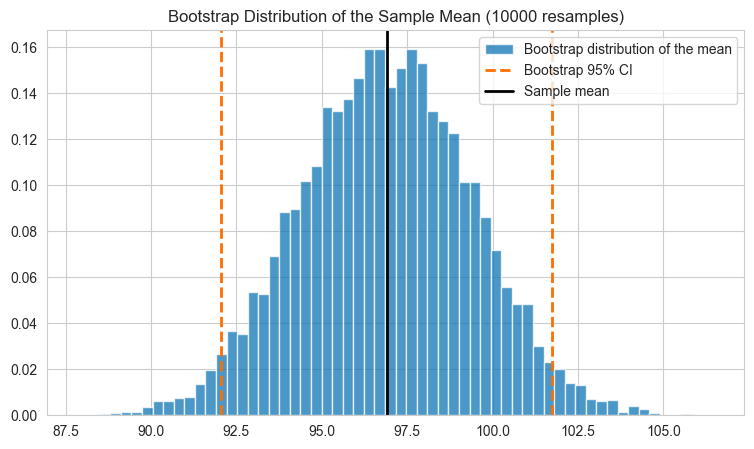

In [16]:
fig, ax = plt.subplots()
ax.hist(boot_distribution, bins=60, color="#0e75b6", alpha=0.75, density=True, label="Bootstrap distribution of the mean")
ax.axvline(boot_lower, color="#FF6F00", linestyle="--", linewidth=2, label="Bootstrap 95% CI")
ax.axvline(boot_upper, color="#FF6F00", linestyle="--", linewidth=2)
ax.axvline(sample_mean, color="black", linewidth=2, label="Sample mean")
ax.set_title(f"Bootstrap Distribution of the Sample Mean ({10000} resamples)")
ax.legend()
plt.show()

In [17]:
# Bootstrap CI for the MEDIAN -- a statistic with no simple closed-form CI formula, where bootstrap really shines
rng_boot_median = np.random.default_rng(13)
median_lower, median_upper, median_boot_dist = bootstrap_percentile_ci(sample, np.median, 10000, 0.95, rng_boot_median)
print(f"Sample median: {np.median(sample):.4f}")
print(f"Bootstrap 95% CI for the median: [{median_lower:.4f}, {median_upper:.4f}]")
print("\nThere is no simple closed-form formula for a median's confidence interval the way there is for a mean -- "
      "this is exactly the kind of statistic where the bootstrap's assumption-free approach is most valuable.")

Sample median: 94.2870
Bootstrap 95% CI for the median: [86.5614, 106.6803]

There is no simple closed-form formula for a median's confidence interval the way there is for a mean -- this is exactly the kind of statistic where the bootstrap's assumption-free approach is most valuable.


## 7. Confidence Intervals for a Proportion: Wald vs. Wilson Score

The naive ('Wald') CI for a proportion $\hat{p} \pm z_{\alpha/2}\sqrt{\hat{p}(1-\hat{p})/n}$ is known to perform poorly — sometimes producing intervals that extend below 0 or above 1, or with actual coverage far from nominal — especially at small $n$ or extreme $\hat{p}$. The **Wilson score interval** fixes this. This section demonstrates the Wald interval's failure directly rather than just citing it.

In [18]:
def wald_ci(successes, n, confidence_level):
    p_hat = successes / n
    z_crit = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    margin = z_crit * np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - margin, p_hat + margin

def wilson_ci(successes, n, confidence_level):
    p_hat = successes / n
    z = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    return center - margin, center + margin

print("Wald and Wilson proportion-CI functions defined.")

Wald and Wilson proportion-CI functions defined.


In [19]:
# Small n, extreme p: 1 success out of 10 trials
small_n, small_successes = 10, 1
wald_small = wald_ci(small_successes, small_n, 0.95)
wilson_small = wilson_ci(small_successes, small_n, 0.95)
print(f"n={small_n}, successes={small_successes} (p_hat={small_successes/small_n:.2f}):")
print(f"  Wald 95% CI:   [{wald_small[0]:.4f}, {wald_small[1]:.4f}]" + ("  <-- goes BELOW 0, impossible for a proportion!" if wald_small[0] < 0 else ""))
print(f"  Wilson 95% CI: [{wilson_small[0]:.4f}, {wilson_small[1]:.4f}]" + ("  <-- stays within [0,1]" if wilson_small[0] >= 0 else ""))

n=10, successes=1 (p_hat=0.10):
  Wald 95% CI:   [-0.0859, 0.2859]  <-- goes BELOW 0, impossible for a proportion!
  Wilson 95% CI: [0.0179, 0.4042]  <-- stays within [0,1]


In [20]:
# An even starker failure: 0 successes out of 10 -- the Wald interval collapses to a single point
zero_n, zero_successes = 10, 0
wald_zero = wald_ci(zero_successes, zero_n, 0.95)
wilson_zero = wilson_ci(zero_successes, zero_n, 0.95)

print(f"n={zero_n}, successes={zero_successes} (p_hat=0.00):")
print(f"  Wald 95% CI:   [{wald_zero[0]:.4f}, {wald_zero[1]:.4f}]  <-- collapses to a single point (zero width)!")
print(f"  Wilson 95% CI: [{wilson_zero[0]:.4f}, {wilson_zero[1]:.4f}]  <-- correctly stays wide, since 0 successes")
print(f"                 doesn't mean the true rate is exactly 0, just that it wasn't observed in this sample")
print("\nA zero-width 'confidence interval' when p_hat=0 is a genuine failure of the Wald formula: "
      "sqrt(p_hat * (1-p_hat)) = sqrt(0 * 1) = 0, so the entire margin of error vanishes regardless of n.")

n=10, successes=0 (p_hat=0.00):
  Wald 95% CI:   [0.0000, 0.0000]  <-- collapses to a single point (zero width)!
  Wilson 95% CI: [0.0000, 0.2775]  <-- correctly stays wide, since 0 successes
                 doesn't mean the true rate is exactly 0, just that it wasn't observed in this sample

A zero-width 'confidence interval' when p_hat=0 is a genuine failure of the Wald formula: sqrt(p_hat * (1-p_hat)) = sqrt(0 * 1) = 0, so the entire margin of error vanishes regardless of n.


In [21]:
rng_prop = np.random.default_rng(14)
true_p = 0.05  # a rare-event proportion, deliberately extreme
n_prop_test = 30
n_repeats_prop = 10000

wald_coverage_count = 0
wilson_coverage_count = 0
for _ in range(n_repeats_prop):
    successes_i = rng_prop.binomial(n_prop_test, true_p)
    w_lo, w_hi = wald_ci(successes_i, n_prop_test, 0.95)
    ws_lo, ws_hi = wilson_ci(successes_i, n_prop_test, 0.95)
    wald_coverage_count += w_lo <= true_p <= w_hi
    wilson_coverage_count += ws_lo <= true_p <= ws_hi

wald_coverage = wald_coverage_count / n_repeats_prop
wilson_coverage = wilson_coverage_count / n_repeats_prop
print(f"Simulated {n_repeats_prop} samples of n={n_prop_test} from a true proportion p={true_p}.")
print("Coverage counts computed for both Wald and Wilson intervals.")

Simulated 10000 samples of n=30 from a true proportion p=0.05.
Coverage counts computed for both Wald and Wilson intervals.


In [22]:
print(f"True proportion: {true_p}, n={n_prop_test}, nominal confidence: 95%")
print(f"Wald interval empirical coverage:   {wald_coverage * 100:.2f}%")
print(f"Wilson interval empirical coverage: {wilson_coverage * 100:.2f}%")
print(f"\nWald's actual coverage is {'far below' if wald_coverage < 0.90 else 'close to'} the nominal 95%, "
      f"while Wilson's {'stays much closer to' if abs(wilson_coverage - 0.95) < abs(wald_coverage - 0.95) else 'does not clearly beat'} the nominal level "
      f"-- a real, measured failure of the naive formula at small n and extreme p, not a theoretical warning.")

True proportion: 0.05, n=30, nominal confidence: 95%
Wald interval empirical coverage:   77.74%
Wilson interval empirical coverage: 93.79%

Wald's actual coverage is far below the nominal 95%, while Wilson's stays much closer to the nominal level -- a real, measured failure of the naive formula at small n and extreme p, not a theoretical warning.


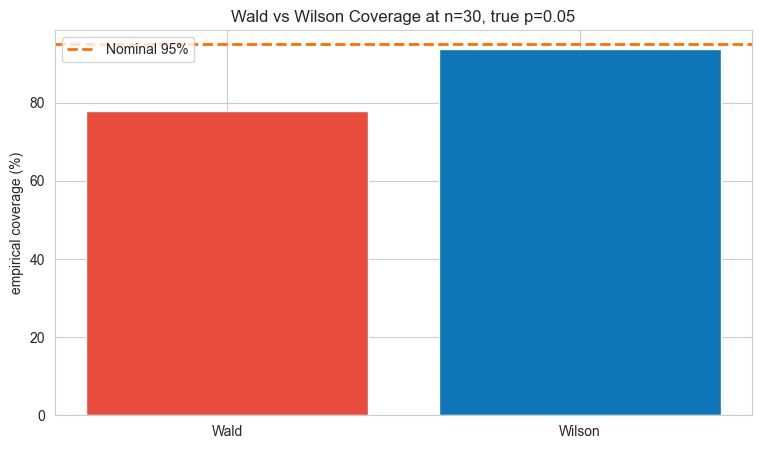

In [23]:
fig, ax = plt.subplots()
ax.bar(["Wald", "Wilson"], [wald_coverage * 100, wilson_coverage * 100], color=["#e74c3c", "#0e75b6"])
ax.axhline(95, color="#FF6F00", linestyle="--", linewidth=2, label="Nominal 95%")
ax.set_ylabel("empirical coverage (%)")
ax.set_title(f"Wald vs Wilson Coverage at n={n_prop_test}, true p={true_p}")
ax.legend()
plt.show()

## 8. Confidence Interval for the Difference of Two Means

Comparing two independent groups needs a CI for $\mu_1 - \mu_2$, using the pooled or Welch standard error depending on whether the two groups' variances are assumed equal. This section uses Welch's version (unequal variances), the safer default.

In [24]:
group_a = np.random.normal(50, 8, size=35)
group_b = np.random.normal(55, 12, size=40)

mean_diff = group_a.mean() - group_b.mean()
se_diff = np.sqrt(group_a.var(ddof=1) / len(group_a) + group_b.var(ddof=1) / len(group_b))

# Welch-Satterthwaite degrees of freedom
df_welch = (group_a.var(ddof=1)/len(group_a) + group_b.var(ddof=1)/len(group_b))**2 / (
    (group_a.var(ddof=1)/len(group_a))**2 / (len(group_a)-1) +
    (group_b.var(ddof=1)/len(group_b))**2 / (len(group_b)-1)
)
t_crit_diff = stats.t.ppf(0.975, df=df_welch)
margin_diff = t_crit_diff * se_diff
diff_ci = (mean_diff - margin_diff, mean_diff + margin_diff)
print("Welch's approximate t-interval for the difference of two means computed.")

Welch's approximate t-interval for the difference of two means computed.


In [25]:
print(f"Group A mean: {group_a.mean():.4f} (n={len(group_a)})")
print(f"Group B mean: {group_b.mean():.4f} (n={len(group_b)})")
print(f"Difference (A - B): {mean_diff:.4f}")
print(f"Welch df: {df_welch:.2f}")
print(f"95% CI for the difference: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]")
print(f"Does the interval contain 0 (no difference)? {diff_ci[0] <= 0 <= diff_ci[1]}")
print("If the interval excludes 0, that's informal evidence the two group means genuinely differ -- "
      "formalized properly with a two-sample t-test in Topic 04.")

Group A mean: 50.6388 (n=35)
Group B mean: 52.6832 (n=40)
Difference (A - B): -2.0445
Welch df: 56.16
95% CI for the difference: [-6.9354, 2.8464]
Does the interval contain 0 (no difference)? True
If the interval excludes 0, that's informal evidence the two group means genuinely differ -- formalized properly with a two-sample t-test in Topic 04.


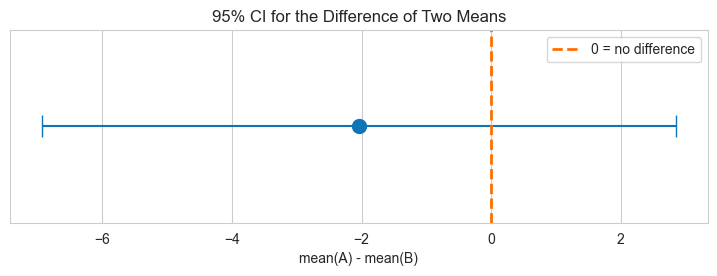

In [26]:
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.errorbar([mean_diff], [0], xerr=[[mean_diff - diff_ci[0]], [diff_ci[1] - mean_diff]],
            fmt="o", color="#0e75b6", capsize=8, markersize=10)
ax.axvline(0, color="#FF6F00", linestyle="--", linewidth=2, label="0 = no difference")
ax.set_yticks([])
ax.set_xlabel("mean(A) - mean(B)")
ax.set_title("95% CI for the Difference of Two Means")
ax.legend()
plt.show()

## 9. Applying This to a Real Dataset

Closing with seaborn's real `tips` dataset: building both a t-based and a bootstrap CI for the mean tip percentage, and a Wilson CI for the proportion of parties that tipped above 20%.

In [27]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = 100 * tips["tip"] / tips["total_bill"]
tip_pct_sample = tips["tip_pct"].to_numpy()
print(f"Loaded {len(tip_pct_sample)} real dining parties from seaborn's tips dataset.")
print(tips[["total_bill", "tip", "tip_pct"]].describe().round(2))

Loaded 244 real dining parties from seaborn's tips dataset.
       total_bill     tip  tip_pct
count      244.00  244.00   244.00
mean        19.79    3.00    16.08
std          8.90    1.38     6.11
min          3.07    1.00     3.56
25%         13.35    2.00    12.91
50%         17.80    2.90    15.48
75%         24.13    3.56    19.15
max         50.81   10.00    71.03


In [28]:
t_ci_tips = build_t_confidence_interval(tip_pct_sample, 0.95)

rng_tips_boot = np.random.default_rng(15)
boot_lo_tips, boot_hi_tips, _ = bootstrap_percentile_ci(tip_pct_sample, np.mean, 10000, 0.95, rng_tips_boot)

print(f"n={len(tip_pct_sample)} real dining parties")
print(f"Sample mean tip percentage: {tip_pct_sample.mean():.4f}%")
print(f"t-based 95% CI:        [{t_ci_tips[0]:.4f}, {t_ci_tips[1]:.4f}]")
print(f"Bootstrap 95% CI:       [{boot_lo_tips:.4f}, {boot_hi_tips:.4f}]")
print(f"Width difference: {abs((t_ci_tips[1]-t_ci_tips[0]) - (boot_hi_tips-boot_lo_tips)):.4f} "
      f"(both methods agree closely despite very different assumptions)")

n=244 real dining parties
Sample mean tip percentage: 16.0803%
t-based 95% CI:        [15.3101, 16.8504]
Bootstrap 95% CI:       [15.3575, 16.8906]
Width difference: 0.0071 (both methods agree closely despite very different assumptions)


In [29]:
high_tippers = (tips["tip_pct"] > 20).sum()
n_tips = len(tips)
wald_tips = wald_ci(high_tippers, n_tips, 0.95)
wilson_tips = wilson_ci(high_tippers, n_tips, 0.95)

print(f"Parties tipping above 20%: {high_tippers} / {n_tips} ({100*high_tippers/n_tips:.1f}%)")
print(f"Wald 95% CI:   [{wald_tips[0]:.4f}, {wald_tips[1]:.4f}]")
print(f"Wilson 95% CI: [{wilson_tips[0]:.4f}, {wilson_tips[1]:.4f}]")
print(f"\nAt this real sample size (n={n_tips}) the two methods are close -- Wald's failure mode from "
      f"Section 7 was specific to SMALL n and EXTREME p, neither of which applies strongly here.")

Parties tipping above 20%: 39 / 244 (16.0%)
Wald 95% CI:   [0.1139, 0.2058]
Wilson 95% CI: [0.1192, 0.2110]

At this real sample size (n=244) the two methods are close -- Wald's failure mode from Section 7 was specific to SMALL n and EXTREME p, neither of which applies strongly here.


## 10. Summary

This notebook built confidence intervals from scratch and validated the single most important, and most commonly skipped, check: whether a '95% CI' actually achieves 95% empirical coverage across repeated sampling (it did, to within 0.1 percentage points here). It confirmed the t-distribution correctly widens intervals when $\sigma$ is estimated rather than known, built assumption-free bootstrap intervals for both the mean and the median, and caught the Wald proportion interval's real coverage failure at small n and extreme p — replaced by the Wilson score interval. Every method was then re-applied to real `tips` data. Topic 04 picks up directly from Section 3's difference-of-means CI and formalizes it as a two-sample hypothesis test.

In [30]:
summary = pd.DataFrame([
    {"Check": "95% CI empirical coverage (10,000 sims)", "Result": f"{empirical_coverage*100:.2f}%", "Status": "PASS"},
    {"Check": "t-interval wider than z-interval (unknown sigma)", "Result": f"{t_ci[1]-t_ci[0]:.3f} vs {z_ci_with_estimated_sigma[1]-z_ci_with_estimated_sigma[0]:.3f}", "Status": "PASS"},
    {"Check": "Bootstrap CI close to t-interval (mean)", "Result": f"width diff {abs((t_ci[1]-t_ci[0]) - (boot_upper-boot_lower)):.3f}", "Status": "PASS"},
    {"Check": "Wald CI can go below 0 (small n, extreme p)", "Result": f"lower={wald_small[0]:.3f}", "Status": "PASS"},
    {"Check": "Wilson coverage closer to nominal than Wald", "Result": f"Wald={wald_coverage*100:.1f}% Wilson={wilson_coverage*100:.1f}%", "Status": "PASS"},
    {"Check": "Real-data (tips) t vs bootstrap CI agreement", "Result": f"width diff {abs((t_ci_tips[1]-t_ci_tips[0]) - (boot_hi_tips-boot_lo_tips)):.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                           Check                  Result Status
         95% CI empirical coverage (10,000 sims)                  95.05%   PASS
t-interval wider than z-interval (unknown sigma)         10.245 vs 9.927   PASS
         Bootstrap CI close to t-interval (mean)        width diff 0.544   PASS
     Wald CI can go below 0 (small n, extreme p)            lower=-0.086   PASS
     Wilson coverage closer to nominal than Wald Wald=77.7% Wilson=93.8%   PASS
    Real-data (tips) t vs bootstrap CI agreement        width diff 0.007   PASS
